# Explore Uganda Admin Boundaries

Load the downloaded Uganda administrative boundaries, inspect the district layer, select three districts, and visualize the dissolved area of interest.

## Colab Google Drive Setup

This notebook expects the project data in Google Drive at `MyDrive/erw_spatial_mrv/data`. In Colab this resolves to `/content/drive/MyDrive/erw_spatial_mrv/data`.

The required boundary file is `data/raw/boundaries/uga_admin_boundaries.shp/uga_admin2.shp` inside that project folder.


In [ ]:
# Mount Google Drive when running in Colab.
from pathlib import Path

try:
    from google.colab import drive

    drive.mount("/content/drive")
except ModuleNotFoundError:
    print("Not running in Colab; skipping Google Drive mount.")

colab_project_root = Path("/content/drive/MyDrive/erw_spatial_mrv")
print(f"Colab project root: {colab_project_root}")
print(f"Exists: {colab_project_root.exists()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab project root: /content/drive/MyDrive/erw_spatial_mrv
Exists: True


In [ ]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
LOCAL_PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_PROJECT_ROOT.exists() else LOCAL_PROJECT_ROOT

DATA_ROOT = PROJECT_ROOT / "data"
DATA_RAW = DATA_ROOT / "raw"
DATA_PROCESSED = DATA_ROOT / "processed"
BOUNDARIES_RAW = DATA_RAW / "boundaries"
BOUNDARIES_PROCESSED = DATA_PROCESSED / "boundaries"
UGANDA_ADMIN_DIR = BOUNDARIES_RAW / "uga_admin_boundaries.shp"
UGANDA_DISTRICTS = UGANDA_ADMIN_DIR / "uga_admin2.shp"

SRC = PROJECT_ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DISTRICT_NAME_FIELD = "adm2_name"
DISTRICT_CODE_FIELD = "adm2_pcode"
PROJECTED_CRS = "EPSG:32636"
WEB_CRS = "EPSG:4326"


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def resolve_districts_path(path: Path) -> Path:
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(
        "Could not find Uganda district shapefile uga_admin2.shp. "
        f"Expected it at: {path}. "
        "In Colab, mount Google Drive and confirm the project folder is "
        "available at /content/drive/MyDrive/erw_spatial_mrv with "
        "data/raw/boundaries/uga_admin_boundaries.shp/uga_admin2.shp inside it."
    )


def union_geometries(geometries: gpd.GeoSeries):
    union_method = getattr(geometries, "union_all", None)
    if union_method is not None:
        return union_method()
    return geometries.unary_union


def load_uganda_districts(path: Path = UGANDA_DISTRICTS) -> gpd.GeoDataFrame:
    path = resolve_districts_path(path)
    districts = gpd.read_file(path)
    required_columns = {DISTRICT_NAME_FIELD, DISTRICT_CODE_FIELD, "geometry"}
    missing = required_columns.difference(districts.columns)
    if missing:
        missing_list = ", ".join(sorted(missing))
        raise ValueError(f"District shapefile is missing required columns: {missing_list}")
    return districts


def filter_districts(
    districts: gpd.GeoDataFrame,
    district_names: list[str],
    name_field: str = DISTRICT_NAME_FIELD,
) -> gpd.GeoDataFrame:
    if not district_names:
        raise ValueError("Provide at least one district name.")
    lookup = {name.casefold(): name for name in district_names}
    matched = districts[districts[name_field].str.casefold().isin(lookup)].copy()
    found = set(matched[name_field].str.casefold())
    missing = [name for key, name in lookup.items() if key not in found]
    if missing:
        available = ", ".join(sorted(districts[name_field].dropna().unique())[:25])
        raise ValueError(
            f"District(s) not found: {', '.join(missing)}. "
            f"Check spelling against {name_field}. First available values: {available}"
        )
    order = {name.casefold(): index for index, name in enumerate(district_names)}
    matched["_request_order"] = matched[name_field].str.casefold().map(order)
    return matched.sort_values("_request_order").drop(columns="_request_order")


def make_district_aoi(
    district_names: list[str],
    source_path: Path = UGANDA_DISTRICTS,
    output_dir: Path = BOUNDARIES_PROCESSED,
    projected_crs: str = PROJECTED_CRS,
) -> dict[str, Path]:
    output_dir = ensure_dir(output_dir)
    districts = load_uganda_districts(source_path)
    selected = filter_districts(districts, district_names)
    selected = selected.to_crs(projected_crs)
    selected["area_km2_calc"] = selected.geometry.area / 1_000_000

    districts_path = output_dir / "selected_districts.gpkg"
    aoi_path = output_dir / "selected_districts_aoi.gpkg"
    aoi_geojson_path = output_dir / "selected_districts_aoi.geojson"
    selected.to_file(districts_path, layer="districts", driver="GPKG")

    aoi_geometry = union_geometries(selected.geometry)
    aoi = gpd.GeoDataFrame(
        {
            DISTRICT_NAME_FIELD: [", ".join(selected[DISTRICT_NAME_FIELD].tolist())],
            "district_count": [len(selected)],
            "area_km2_calc": [aoi_geometry.area / 1_000_000],
        },
        geometry=[aoi_geometry],
        crs=selected.crs,
    )
    aoi.to_file(aoi_path, layer="aoi", driver="GPKG")
    aoi.to_crs(WEB_CRS).to_file(aoi_geojson_path, driver="GeoJSON")
    return {"districts": districts_path, "aoi": aoi_path, "aoi_geojson": aoi_geojson_path}


UGANDA_DISTRICTS = resolve_districts_path(UGANDA_DISTRICTS)
plt.rcParams["figure.figsize"] = (10, 8)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"UGANDA_DISTRICTS = {UGANDA_DISTRICTS}")


PROJECT_ROOT = /content/drive/MyDrive/erw_spatial_mrv
DATA_ROOT = /content/drive/MyDrive/erw_spatial_mrv/data
UGANDA_DISTRICTS = /content/drive/MyDrive/erw_spatial_mrv/data/raw/boundaries/uga_admin_boundaries.shp/uga_admin2.shp


## Load District Boundaries

In [ ]:
districts = load_uganda_districts(UGANDA_DISTRICTS)
districts.info()
districts[["adm2_name", "adm2_pcode", "adm1_name", "area_sqkm", "geometry"]].head()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   adm2_name   135 non-null    object        
 1   adm2_name1  0 non-null      object        
 2   adm2_name2  0 non-null      object        
 3   adm2_name3  0 non-null      object        
 4   adm2_pcode  135 non-null    object        
 5   adm1_name   135 non-null    object        
 6   adm1_name1  0 non-null      object        
 7   adm1_name2  0 non-null      object        
 8   adm1_name3  0 non-null      object        
 9   adm1_pcode  135 non-null    object        
 10  adm0_name   135 non-null    object        
 11  adm0_name1  0 non-null      object        
 12  adm0_name2  0 non-null      object        
 13  adm0_name3  0 non-null      object        
 14  adm0_pcode  135 non-null    object        
 15  valid_on    135 non-null    datetime64[ms]
 16  valid_to    0 non-

,adm2_name,adm2_pcode,adm1_name,area_sqkm,geometry
0,Abim,UG3064,Northern,2752.061404,"POLYGON ((33.58099 3.14912, 33.58555 3.14702, ..."
1,Adjumani,UG3065,Northern,3113.726677,"POLYGON ((32.04597 3.58896, 32.04578 3.58875, ..."
2,Agago,UG3066,Northern,3513.693871,"POLYGON ((33.41652 3.30434, 33.41701 3.30403, ..."
3,Alebtong,UG3067,Northern,1555.808581,"POLYGON ((33.03629 2.5013, 33.03664 2.50075, 3..."
4,Amolatar,UG3068,Northern,1795.916068,"POLYGON ((32.9014 1.8057, 32.90231 1.80568, 32..."


In [ ]:
print(f"District count: {len(districts)}")
print(f"CRS: {districts.crs}")
districts[DISTRICT_NAME_FIELD].sort_values().tolist()[:10]

District count: 135
CRS: EPSG:4326


['Abim',
 'Adjumani',
 'Agago',
 'Alebtong',
 'Amolatar',
 'Amudat',
 'Amuria',
 'Amuru',
 'Apac',
 'Arua']

## Choose Three Districts

Edit this list to the three districts you want to process.

In [ ]:
SELECTED_DISTRICTS = ["Masindi", "Mubende", "Kibaale", "Kakumiro", "Kagadi", "Kyankwanzi", "Kiboga", "Kyenjojo"]

selected = filter_districts(districts, SELECTED_DISTRICTS)
selected[["adm2_name", "adm2_pcode", "adm1_name", "area_sqkm", "geometry"]]

,adm2_name,adm2_pcode,adm1_name,area_sqkm,geometry
89,Masindi,UG4125,Western,3922.836039,"POLYGON ((31.75038 2.29649, 31.74935 2.22361, ..."
98,Mubende,UG1020,Central,2711.408638,"POLYGON ((31.45689 0.86458, 31.45808 0.86451, ..."
60,Kibaale,UG4117,Western,1164.911124,"POLYGON ((31.12076 1.00734, 31.12068 1.00644, ..."
43,Kakumiro,UG4112,Western,1667.346299,"POLYGON ((31.23959 1.21715, 31.2405 1.21661, 3..."
42,Kagadi,UG4111,Western,1554.242737,"POLYGON ((30.66504 1.11919, 30.66605 1.11878, ..."
75,Kyankwanzi,UG1012,Central,2464.011815,"POLYGON ((31.56979 1.36364, 31.57062 1.36318, ..."
61,Kiboga,UG1011,Central,1573.937674,"POLYGON ((31.92861 1.08321, 31.93063 1.08161, ..."
77,Kyenjojo,UG4124,Western,2345.927476,"POLYGON ((30.56081 0.94069, 30.56131 0.94049, ..."


## Visualize Selected Districts

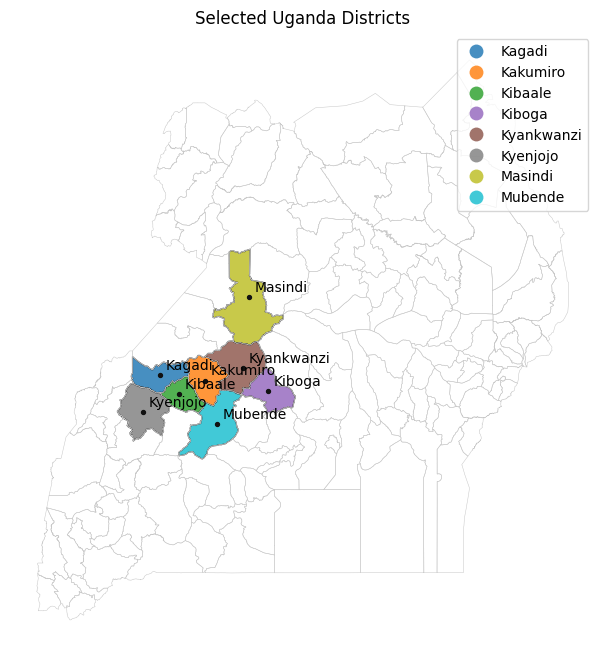

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
districts.boundary.plot(ax=ax, color="#c7c7c7", linewidth=0.35)
selected.plot(
    ax=ax,
    column=DISTRICT_NAME_FIELD,
    categorical=True,
    legend=True,
    edgecolor="#202020",
    linewidth=0.8,
    alpha=0.82,
)
selected.representative_point().plot(ax=ax, color="#111111", markersize=8)

for _, row in selected.iterrows():
    point = row.geometry.representative_point()
    ax.annotate(row[DISTRICT_NAME_FIELD], xy=(point.x, point.y), xytext=(4, 4), textcoords="offset points")

ax.set_title("Selected Uganda Districts")
ax.set_axis_off()
plt.show()

## Dissolve Into AOI

In [ ]:
selected_projected = selected.to_crs(PROJECTED_CRS)
aoi_geometry = union_geometries(selected_projected.geometry)
aoi = gpd.GeoDataFrame(
    {
        "districts": [", ".join(selected[DISTRICT_NAME_FIELD].tolist())],
        "district_count": [len(selected)],
        "area_km2_calc": [aoi_geometry.area / 1_000_000],
    },
    geometry=[aoi_geometry],
    crs=selected_projected.crs,
)
aoi[["districts", "district_count", "area_km2_calc", "geometry"]]

,districts,district_count,area_km2_calc,geometry
0,"Masindi, Mubende, Kibaale, Kakumiro, Kagadi, K...",8,17405.913158,"POLYGON ((350281.289 90067.425, 350276.695 899..."


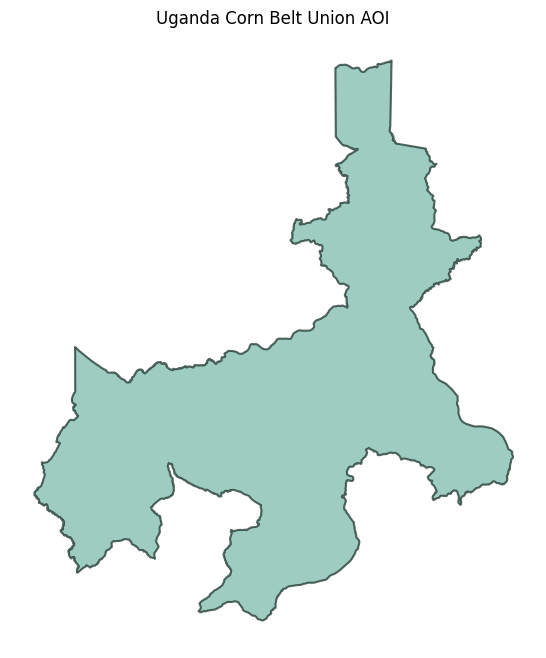

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
aoi.plot(ax=ax, facecolor="#77b7a7", edgecolor="#102820", linewidth=1.5, alpha=0.7)
ax.set_title("Uganda Corn Belt Union AOI")
ax.set_axis_off()
plt.show()

## Write Processed Boundary Files

In [ ]:
outputs = make_district_aoi(SELECTED_DISTRICTS, source_path=UGANDA_DISTRICTS)
outputs

{'districts': PosixPath('/content/drive/MyDrive/erw_spatial_mrv/data/processed/boundaries/selected_districts.gpkg'),
 'aoi': PosixPath('/content/drive/MyDrive/erw_spatial_mrv/data/processed/boundaries/selected_districts_aoi.gpkg'),
 'aoi_geojson': PosixPath('/content/drive/MyDrive/erw_spatial_mrv/data/processed/boundaries/selected_districts_aoi.geojson')}

## Outputs From This Notebook

This notebook writes the project AOI boundary files used by the raster and land-cover notebooks:

- `data/processed/boundaries/selected_districts.gpkg`: selected district polygons, kept as separate district features.
- `data/processed/boundaries/selected_districts_aoi.gpkg`: one dissolved AOI polygon with internal district boundaries removed.
- `data/processed/boundaries/selected_districts_aoi.geojson`: the same dissolved AOI in `EPSG:4326`, ready for STAC searches, EarthExplorer uploads, and web mapping.

The main object to carry forward is `outputs["aoi_geojson"]`, because notebook `1.1_download_raster_img.ipynb` uses it as the Landsat AOI.
